In [1]:
!pip install -q pandas numpy bertopic sentence-transformers umap-learn hdbscan beautifulsoup4

from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 7.3 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
!pip install -q pandas numpy bertopic sentence-transformers umap-learn hdbscan beautifulsoup4

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
from bs4 import BeautifulSoup

# 你的 ai+ed.tsv 路径（根据你之前说的）
INPUT_TSV  = "/content/drive/MyDrive/ai_media_discourse/ai+ed.tsv"
OUTPUT_WITH_TOPICS = "/content/drive/MyDrive/ai_media_discourse/ai_ed_with_topics.csv"
OUTPUT_YEAR_TOPIC  = "/content/drive/MyDrive/ai_media_discourse/ai_ed_topics_by_year.csv"

df_ed = pd.read_csv(INPUT_TSV, sep="\t", on_bad_lines="skip")
print("总文章数：", len(df_ed))
print("列名：", df_ed.columns.tolist())
print(df_ed.head(3))


总文章数： 29138
列名： ['id', 'pubtime', 'medium_code', 'medium_name', 'rubric', 'regional', 'doctype', 'doctype_description', 'language', 'char_count', 'dateline', 'head', 'subhead', 'article_link', 'content_id', 'content']
         id                 pubtime medium_code                 medium_name  \
0  54649159  2024-09-09 17:58:58+02        CASO                     cash.ch   
1  52069904  2023-12-09 00:00:00+01        BEOL           Berner Oberländer   
2  52069885  2023-12-09 00:00:00+01         LAT  BZ - Langenthaler Tagblatt   

       rubric regional doctype       doctype_description language  char_count  \
0         NaN      NaN     WWE             Online medium       de       11356   
1  Wirtschaft      NaN     PRD  Regional daily newspaper       de        7151   
2  Wirtschaft      NaN     PRD  Regional daily newspaper       de        7151   

  dateline                                               head subhead  \
0      NaN  Cembra-CEO: «Wir planen, die Dividende im Eink...     N

In [4]:
# 解析 content 里的 HTML，变成纯文本
def parse_html(text):
    if pd.isna(text):
        return ""
    return BeautifulSoup(str(text), "html.parser").get_text(separator=" ")

df_ed["content_plain"] = df_ed["content"].apply(parse_html)

# 构造用于 BERTopic 的文本：
#   标题 + 副标题 + 前 4000 字正文（防止单篇太长炸内存）
MAX_CHARS = 4000

df_ed["text_for_topic"] = (
    df_ed["head"].fillna("").astype(str) + ". " +
    df_ed["subhead"].fillna("").astype(str) + ". " +
    df_ed["content_plain"].fillna("").astype(str).str.slice(0, MAX_CHARS)
)

print("示例 text_for_topic：")
print(df_ed["text_for_topic"].iloc[0][:1000])


示例 text_for_topic：
Cembra-CEO: «Wir planen, die Dividende im Einklang mit nachhaltigem Gewinnwachstum ansteigen zu lassen». . Holger Laubenthal, CEO von Cembra Money Bank, äussert sich im cash-Interview zur Aktienkursentwicklung, der Dividendenpolitik und zum Geschäftsgang. Manuel Boeck Holger Laubenthal, CEO von Cembra Money Bank. Quelle: ZVG cash.ch: Die Aktien von Cembra haben seit Jahresbeginn um 20 Prozent zugelegt. Was sind Ihrer Meinung nach die Hauptgründe für diese positive Entwicklung? Holger Laubenthal: Es wird anerkannt, dass wir in der Umsetzung unserer Strategie gut vorankommen. Ein Beispiel dafür ist die neue Banking-Plattform für das Leasinggeschäft, die wir eingeführt haben, sowie unsere Aktivitäten auf der kommerziellen Seite, wie etwa die stetige Weiterentwicklung der Cembra App. Die Automatisierung und Digitalisierung führen zu den Effizienzgewinnen, die wir uns vorgenommen haben, und die sich nun in den Zahlen widerspiegeln. Kursentwicklung der Cembra-Aktien. Geht 

In [5]:
# pubtime -> year
df_ed["pubtime_str"] = df_ed["pubtime"].astype(str)
df_ed["pubtime_dt"] = pd.to_datetime(
    df_ed["pubtime_str"],
    errors="coerce",
    utc=True
)
df_ed["year"] = df_ed["pubtime_dt"].dt.year

print(df_ed[["pubtime", "pubtime_dt", "year"]].head())
print("year 有效的文章数：", df_ed["year"].notna().sum())


                  pubtime                pubtime_dt  year
0  2024-09-09 17:58:58+02 2024-09-09 15:58:58+00:00  2024
1  2023-12-09 00:00:00+01 2023-12-08 23:00:00+00:00  2023
2  2023-12-09 00:00:00+01 2023-12-08 23:00:00+00:00  2023
3  2023-12-09 00:00:00+01 2023-12-08 23:00:00+00:00  2023
4  2023-12-09 00:00:00+01 2023-12-08 23:00:00+00:00  2023
year 有效的文章数： 29138


In [6]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import torch

# 选择设备
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# SentenceTransformer 模型（多语种，小一点）
EMBED_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
s_model = SentenceTransformer(EMBED_MODEL, device=device)

# 准备文本
docs = df_ed["text_for_topic"].fillna("").tolist()

# 生成句向量
embeddings = s_model.encode(docs, show_progress_bar=True, convert_to_numpy=True)

# 降维 + 聚类的 UMAP / HDBSCAN 由 BERTopic 内部处理（用默认即可）
topic_model_ed = BERTopic(min_topic_size=10, verbose=True)

topics_ed, probs_ed = topic_model_ed.fit_transform(docs, embeddings)

# 写回 df
df_ed["topic"] = topics_ed

# 主题信息表
topic_info_ed = topic_model_ed.get_topic_info()
print("发现的主题数（含 -1 噪音）：", topic_info_ed.shape[0])
display(topic_info_ed.head(20))


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Using device: cuda


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/911 [00:00<?, ?it/s]

2025-11-29 16:39:13,607 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-29 16:39:47,219 - BERTopic - Dimensionality - Completed ✓
2025-11-29 16:39:47,220 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-29 16:39:50,650 - BERTopic - Cluster - Completed ✓
2025-11-29 16:39:50,663 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-29 16:40:04,338 - BERTopic - Representation - Completed ✓


发现的主题数（含 -1 噪音）： 953


,Topic,Count,Name,Representation,Representative_Docs
0,-1,5267,-1_ki_und_zu_von,"[ki, und, zu, von, im, das, ist, mit, die, fr]","[«Jeder muss sich überlegen, was KI für den Jo..."
1,0,590,0_herisau_appenzeller_uhr_appenzell,"[herisau, appenzeller, uhr, appenzell, appenze...",[Jägernachwuchs in Appenzell Ausserrhoden +++ ...
2,1,325,1_flle_fallzahlen_belegung_sequenzierungen,"[flle, fallzahlen, belegung, sequenzierungen, ...",[Wie entwickeln sich die kantonalen und nation...
3,2,296,2_omikron_flle_impfstoff_anteil,"[omikron, flle, impfstoff, anteil, sequenzieru...",[Wie entwickeln sich die kantonalen und nation...
4,3,282,3_impfstoff_fallzahlen_belegung_impfstatus,"[impfstoff, fallzahlen, belegung, impfstatus, ...",[Wie entwickeln sich die kantonalen und nation...
5,4,275,4_intensivstationen_fallzahlen_belegung_grafik,"[intensivstationen, fallzahlen, belegung, graf...",[Wie entwickeln sich die kantonalen und nation...
6,5,175,5_umsatz_tiefrote_tagesaktuellen_nachrichtenre...,"[umsatz, tiefrote, tagesaktuellen, nachrichten...",[Lonza steigert Gewinn deutlich ++ Emmi mit Um...
7,6,160,6_rektorin_timon_lehrpersonen_gerber,"[rektorin, timon, lehrpersonen, gerber, studer...",[«Die Lernenden-Suche ist ein Kampf». . Offene...
8,7,139,7_wil_fc_wiler_flawil,"[wil, fc, wiler, flawil, juli, region, pd, uhr...",[Nasskalter Wiler Sonntagsverkauf nicht schlec...
9,8,137,8_impfungen_14tagesinzidenz_statistik_geimpft,"[impfungen, 14tagesinzidenz, statistik, geimpf...",[Wie entwickeln sich die kantonalen und nation...


In [7]:
# 1) 生成一个方便查名字的小函数
def get_topic_name(tid):
    if tid == -1:
        return "outlier"
    info = topic_model_ed.get_topic_info()
    if tid in info.Topic.values:
        return info.loc[info.Topic == tid, "Name"].values[0]
    return "unknown"

# 写回每篇文章的主题名
df_ed["topic_name"] = df_ed["topic"].apply(get_topic_name)

# 2) 定义“教育相关”的关键词
edu_keywords = {
    "schule", "schulen", "unterricht", "bildung", "universität", "hochschule",
    "student", "studenten", "studierende", "schüler", "schülerin", "lehrer",
    "lehrerin", "pädagogik", "klassen", "klasse", "kurs", "prüfung",
    "ausbildung", "weiterbildung", "lernen", "lernenden", "dozent", "dozentin",
    "campus", "seminar", "vorlesung"
}

def topic_education_flag(topic_id):
    if topic_id == -1:
        return False
    topic = topic_model_ed.get_topic(topic_id)
    if topic is None:
        return False
    words = [w for w, _ in topic]
    words_lower = {w.lower() for w in words}
    return len(words_lower & edu_keywords) > 0

topic_info_ed["is_edu_related"] = topic_info_ed["Topic"].apply(topic_education_flag)

print("主题表（前 20 行，含教育相关标记）：")
display(topic_info_ed.head(20))


主题表（前 20 行，含教育相关标记）：


,Topic,Count,Name,Representation,Representative_Docs,is_edu_related
0,-1,5267,-1_ki_und_zu_von,"[ki, und, zu, von, im, das, ist, mit, die, fr]","[«Jeder muss sich überlegen, was KI für den Jo...",False
1,0,590,0_herisau_appenzeller_uhr_appenzell,"[herisau, appenzeller, uhr, appenzell, appenze...",[Jägernachwuchs in Appenzell Ausserrhoden +++ ...,False
2,1,325,1_flle_fallzahlen_belegung_sequenzierungen,"[flle, fallzahlen, belegung, sequenzierungen, ...",[Wie entwickeln sich die kantonalen und nation...,False
3,2,296,2_omikron_flle_impfstoff_anteil,"[omikron, flle, impfstoff, anteil, sequenzieru...",[Wie entwickeln sich die kantonalen und nation...,False
4,3,282,3_impfstoff_fallzahlen_belegung_impfstatus,"[impfstoff, fallzahlen, belegung, impfstatus, ...",[Wie entwickeln sich die kantonalen und nation...,False
5,4,275,4_intensivstationen_fallzahlen_belegung_grafik,"[intensivstationen, fallzahlen, belegung, graf...",[Wie entwickeln sich die kantonalen und nation...,False
6,5,175,5_umsatz_tiefrote_tagesaktuellen_nachrichtenre...,"[umsatz, tiefrote, tagesaktuellen, nachrichten...",[Lonza steigert Gewinn deutlich ++ Emmi mit Um...,False
7,6,160,6_rektorin_timon_lehrpersonen_gerber,"[rektorin, timon, lehrpersonen, gerber, studer...",[«Die Lernenden-Suche ist ein Kampf». . Offene...,True
8,7,139,7_wil_fc_wiler_flawil,"[wil, fc, wiler, flawil, juli, region, pd, uhr...",[Nasskalter Wiler Sonntagsverkauf nicht schlec...,False
9,8,137,8_impfungen_14tagesinzidenz_statistik_geimpft,"[impfungen, 14tagesinzidenz, statistik, geimpf...",[Wie entwickeln sich die kantonalen und nation...,False


In [8]:
# 先把 year 可用的文章筛出来
df_year_ok = df_ed.dropna(subset=["year"]).copy()
df_year_ok["year"] = df_year_ok["year"].astype(int)

# 合并一下教育相关标记到文章上
topic_flag_map = topic_info_ed.set_index("Topic")["is_edu_related"].to_dict()
df_year_ok["is_edu_topic"] = df_year_ok["topic"].map(topic_flag_map)

# 按年份 + topic 聚合
year_topic_stats = (
    df_year_ok
    .groupby(["year", "topic", "topic_name", "is_edu_topic"])
    .size()
    .reset_index(name="n_articles")
    .sort_values(["year", "n_articles"], ascending=[True, False])
)

display(year_topic_stats.head(30))

# 也保存一份到文件，方便你用 Excel / R / Python 画图或做 pivot
year_topic_stats.to_csv(OUTPUT_YEAR_TOPIC, index=False)
print("按年份的主题统计已保存到：", OUTPUT_YEAR_TOPIC)
top_k = 10

top_year_topic = (
    year_topic_stats
    .groupby("year")
    .head(top_k)
    .reset_index(drop=True)
)

print("每年 Top-10 主题：")
display(top_year_topic)


,year,topic,topic_name,is_edu_topic,n_articles
0,2020,-1,outlier,False,411
1,2020,0,0_herisau_appenzeller_uhr_appenzell,False,179
6,2020,10,10_stgaller_stgallen_stadtticker_november,False,117
103,2020,202,202_husten_hustens_hustentnen_erkennungsquote,False,27
105,2020,206,206_kurve_lehner_rea_geradeaus,False,25
119,2020,252,252_twitteraccounts_accounts_kapern_sabotage,False,25
99,2020,193,193_csillaghy_flares_flarecast_sonne,False,24
126,2020,277,277_schafheitle_algorithmus_hiring_shortlist,False,23
81,2020,159,159_tiktok_deal_bytedance_trump,False,22
148,2020,355,355_gesichtserkennung_berwachungskameras_rassi...,False,22


按年份的主题统计已保存到： /content/drive/MyDrive/ai_media_discourse/ai_ed_topics_by_year.csv
每年 Top-10 主题：


,year,topic,topic_name,is_edu_topic,n_articles
0,2020,-1,outlier,False,411
1,2020,0,0_herisau_appenzeller_uhr_appenzell,False,179
2,2020,10,10_stgaller_stgallen_stadtticker_november,False,117
3,2020,202,202_husten_hustens_hustentnen_erkennungsquote,False,27
4,2020,206,206_kurve_lehner_rea_geradeaus,False,25
5,2020,252,252_twitteraccounts_accounts_kapern_sabotage,False,25
6,2020,193,193_csillaghy_flares_flarecast_sonne,False,24
7,2020,277,277_schafheitle_algorithmus_hiring_shortlist,False,23
8,2020,159,159_tiktok_deal_bytedance_trump,False,22
9,2020,355,355_gesichtserkennung_berwachungskameras_rassi...,False,22


In [9]:
# 你的教育关键词
edu_keywords = {
    "schule", "schulen", "unterricht", "bildung", "universität", "hochschule",
    "student", "studenten", "studierende", "schüler", "schülerin", "lehrer",
    "lehrpersonen", "pädagogik", "campus", "vorlesung", "prüfung"
}

# Step 1: 识别教育主题
def is_edu_topic_by_words(topic_id):
    if topic_id == -1:
        return False
    topic_words = topic_model_ed.get_topic(topic_id)
    if topic_words is None:
        return False
    tokens = {w.lower() for w, _ in topic_words}
    return len(tokens & edu_keywords) > 0

# 新增 education flag
topic_info_ed["edu_flag_secondary"] = topic_info_ed["Topic"].apply(is_edu_topic_by_words)

# 合并主/次判断
topic_info_ed["edu_flag_final"] = (
    topic_info_ed["is_edu_related"] |
    topic_info_ed["edu_flag_secondary"]
)

# 选出教育主题 ID
edu_topics = topic_info_ed[topic_info_ed["edu_flag_final"] == True]["Topic"].tolist()
print("Education-related topics:", edu_topics)

# 从文章 df 中筛出教育文章
df_edu = df_ed[df_ed["topic"].isin(edu_topics)].copy()
print("教育相关文章数：", len(df_edu))


Education-related topics: [6, 22, 27, 29, 49, 50, 72, 81, 115, 140, 145, 178, 185, 268, 336, 339, 374, 381, 392, 428, 439, 460, 468, 516, 632, 696, 723, 737, 739, 741, 759, 761, 762, 820, 833, 870, 892, 896, 906, 917, 929]
教育相关文章数： 1147


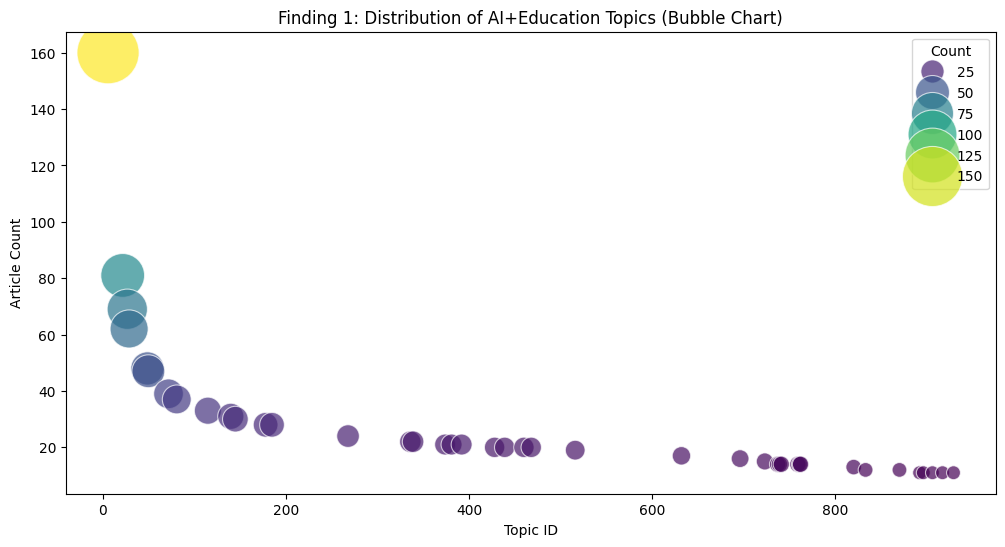

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

bubble_df = (
    df_edu.groupby("topic")
    .size()
    .reset_index(name="count")
    .merge(topic_info_ed[["Topic", "Name"]], left_on="topic", right_on="Topic")
)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=bubble_df,
    x="topic",
    y="count",
    size="count",
    hue="count",
    sizes=(100, 2000),
    alpha=0.7,
    palette="viridis"
)

plt.title("Finding 1: Distribution of AI+Education Topics (Bubble Chart)")
plt.xlabel("Topic ID")
plt.ylabel("Article Count")
plt.legend(title="Count")
plt.show()


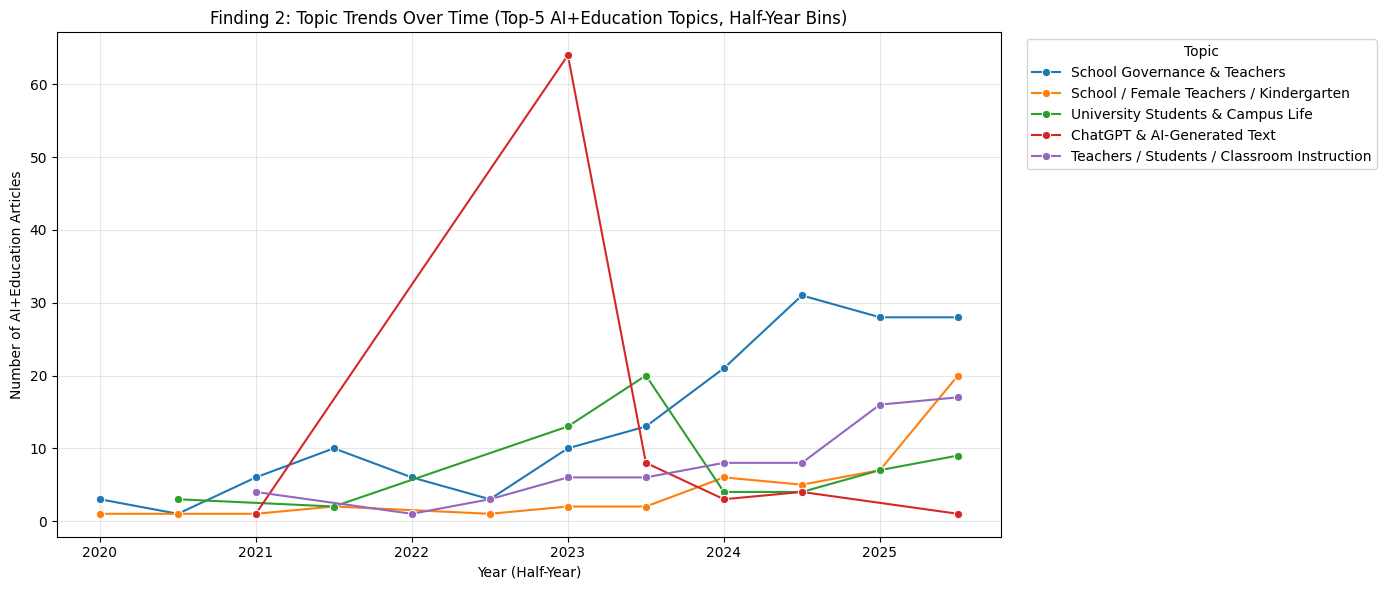

In [16]:
# 英文 Topic Label（你可以自己修改成更短/更正式的）
topic_english_labels = {
    6:  "School Governance & Teachers",
    49: "School / Female Teachers / Kindergarten",
    29: "University Students & Campus Life",
    22: "ChatGPT & AI-Generated Text",
    27: "Teachers / Students / Classroom Instruction"
}
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========= 1) half-year 时间 bin =========
df_edu["time_bin"] = (
    df_edu["pubtime_dt"].dt.year
    + (df_edu["pubtime_dt"].dt.month > 6) * 0.5
)

# ========= 2) 选 Top-K 教育主题 =========
top_k = 5

topic_sizes = (
    df_edu.groupby("topic")
    .size()
    .sort_values(ascending=False)
)

top_k_ids = topic_sizes.head(top_k).index.tolist()
df_edu_topk = df_edu[df_edu["topic"].isin(top_k_ids)].copy()

# ========= 2.5）英文 topic label =========
topic_english_labels = {
    6:  "School Governance & Teachers",
    49: "School / Female Teachers / Kindergarten",
    29: "University Students & Campus Life",
    22: "ChatGPT & AI-Generated Text",
    27: "Teachers / Students / Classroom Instruction"
}

# ========= 3) 按半年统计数量 =========
trend_df = (
    df_edu_topk
    .groupby(["time_bin", "topic"])
    .size()
    .reset_index(name="count")
)

# ========= 4) 添加英文标签 =========
trend_df["topic_label"] = trend_df["topic"].map(topic_english_labels)

# ========= 5) 画图 =========
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=trend_df,
    x="time_bin",
    y="count",
    hue="topic_label",
    marker="o"
)

plt.title("Finding 2: Topic Trends Over Time (Top-5 AI+Education Topics, Half-Year Bins)")
plt.xlabel("Year (Half-Year)")
plt.ylabel("Number of AI+Education Articles")
plt.grid(True, alpha=0.3)
plt.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Top-K 教育主题 ID： [6, 22, 27, 29, 49]


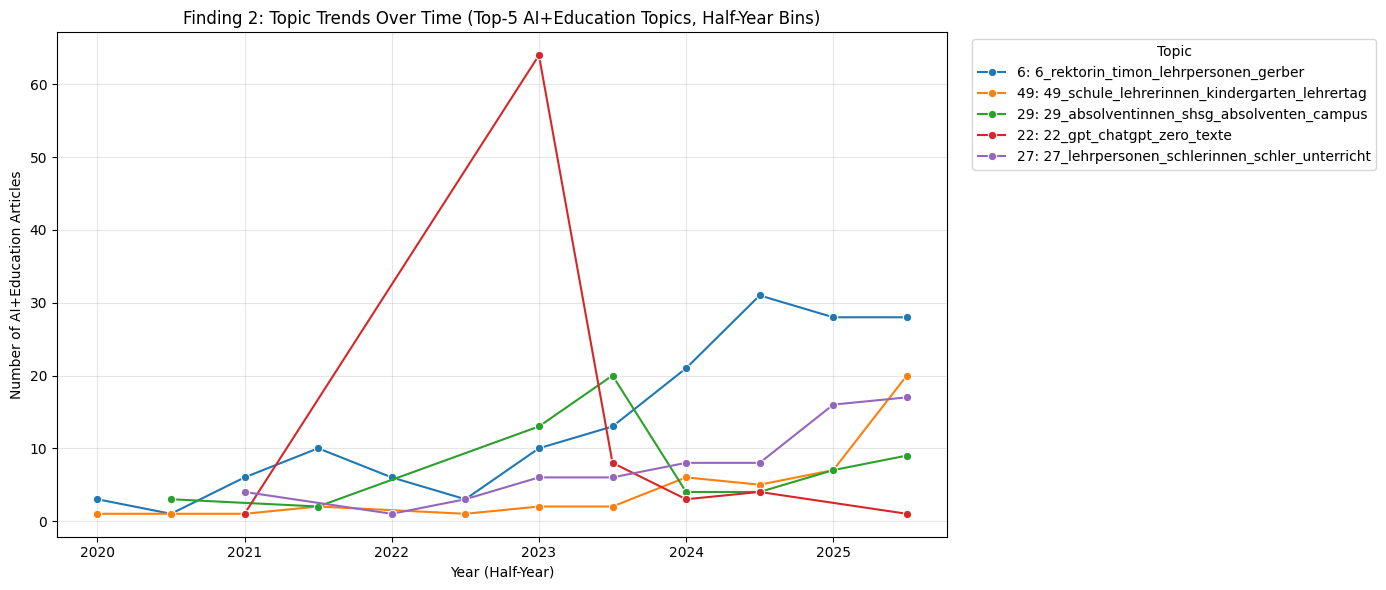

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========= 1) half-year 时间 bin =========
# 上半年：2023.0，下半年：2023.5
df_edu["time_bin"] = (
    df_edu["pubtime_dt"].dt.year
    + (df_edu["pubtime_dt"].dt.month > 6) * 0.5
)

# ========= 2) 先按 topic 统计总量，选 Top-K =========
top_k = 5  # 想看前几个教育主题可以改这个数

topic_sizes = (
    df_edu.groupby("topic")
    .size()
    .sort_values(ascending=False)
)

top_k_ids = topic_sizes.head(top_k).index.tolist()
print("Top-K 教育主题 ID：", top_k_ids)

# 只保留这几个最大的教育主题
df_edu_topk = df_edu[df_edu["topic"].isin(top_k_ids)].copy()

# ========= 3) 按 (time_bin, topic) 统计每半年数量 =========
trend_df = (
    df_edu_topk
    .groupby(["time_bin", "topic"])
    .size()
    .reset_index(name="count")
)

# ========= 4) 合并上 BERTopic 给的 Name，做一个可读的 label =========
trend_df = trend_df.merge(
    topic_info_ed[["Topic", "Name"]],
    left_on="topic",
    right_on="Topic",
    how="left"
)

# 例如：22: gpt_chatgpt_zero_texte
trend_df["topic_label"] = trend_df["topic"].astype(str) + ": " + trend_df["Name"]

# ========= 5) 画折线图（只画 Top-K 主题） =========
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=trend_df,
    x="time_bin",
    y="count",
    hue="topic_label",
    marker="o"
)

plt.title("Finding 2: Topic Trends Over Time (Top-{} AI+Education Topics, Half-Year Bins)".format(top_k))
plt.xlabel("Year (Half-Year)")
plt.ylabel("Number of AI+Education Articles")
plt.grid(True, alpha=0.3)
plt.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [12]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

df_edu["sentiment"] = df_edu["text_for_topic"].apply(
    lambda x: sentiment_model(x[:500])[0]["label"]  # 截断避免过长
)

print(df_edu["sentiment"].value_counts())


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


sentiment
1 star     376
4 stars    332
3 stars    186
2 stars    151
5 stars    102
Name: count, dtype: int64


In [13]:
sent_by_year = df_edu.groupby("year")["sentiment"].value_counts(normalize=True).unstack().fillna(0)
print(sent_by_year)


sentiment    1 star   2 stars   3 stars   4 stars   5 stars
year                                                       
2020       0.483871  0.161290  0.064516  0.258065  0.032258
2021       0.132075  0.358491  0.169811  0.245283  0.094340
2022       0.379310  0.206897  0.103448  0.241379  0.068966
2023       0.274436  0.146617  0.139098  0.293233  0.146617
2024       0.411960  0.063123  0.199336  0.232558  0.093023
2025       0.308219  0.130137  0.164384  0.340183  0.057078


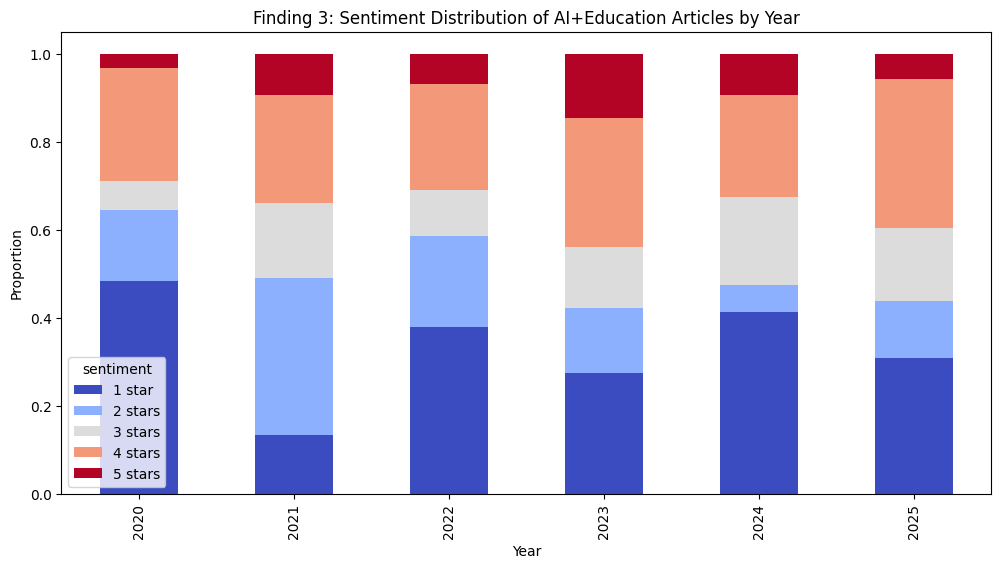

In [14]:
sent_by_year.plot(kind="bar", figsize=(12, 6), stacked=True, colormap="coolwarm")
plt.title("Finding 3: Sentiment Distribution of AI+Education Articles by Year")
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.show()
